Hier mal die main


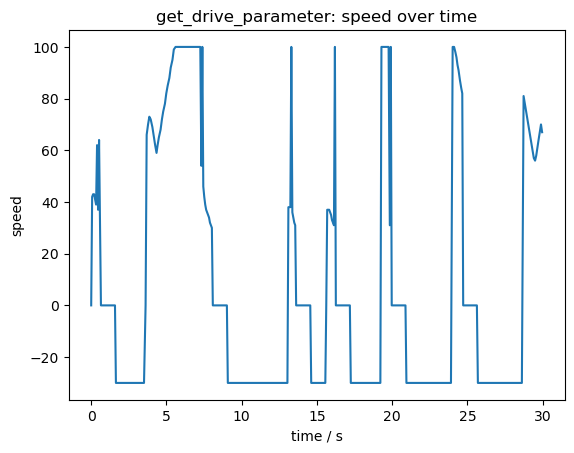

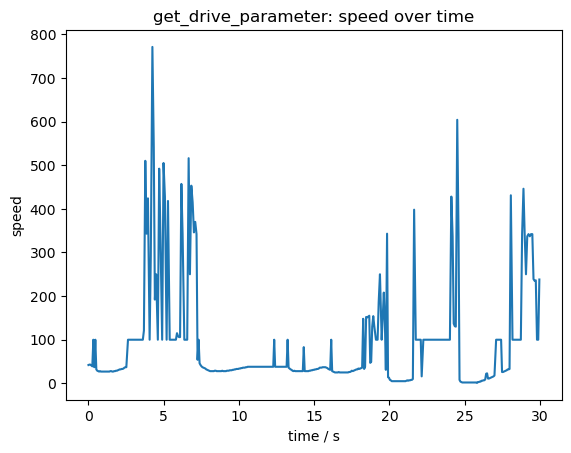

In [ ]:
from basisklassen import BackWheels, FrontWheels, Ultrasonic
from BaseCar import *
import time
import random

import matplotlib.pyplot as plt
import numpy as np

from concurrent.futures import ThreadPoolExecutor
from threading import Lock, Event


class SonicCar(BaseCar):
    """Lässt das Auto mittels des Ultraschallsensor (Abstandmessung) fahren

    Args:
        BaseCar (object): Basisklasse des Autos - Kann nur Lenkung und Geschwindigkeit einstellen
    """

    def __init__(self):
        """Initiert das Object 'SonicCar' und über super-init die Methoden aus 'BaseCar'
        """        
        self.us = Ultrasonic()

        # Thread-sicher
        self._sensor_lock = Lock() # Schließt die Daten (_latest_distacen und _latest_dietance_time) so, dass nur einer darauf zugreifen kann (Thread 1 oder 2), nciht gleichzeitig
        self._sensor_ready = Event() # Ist eine Flag, ob aktuelle Werte da sind -> Wenn ja, der andere kann sich den aktuelln Wert holen wenn nicht gelockt ist
        self._latest_distance = None
        self._latest_distance_time = None

        # Super init - Damit ein Object initiiert wird die auch BaseCar kennt (Methoden der BaseCar)
        super().__init__()

    def _set_latest_distance(self, distance_value: int):
        """Greift auf den letzten Sensorwert zu

        Args:
            distance_value (int): Sensorwert
        """        
        with self._sensor_lock: # Wenn _sensor_lock frei ist, können Daten geschrieben werden
            self._latest_distance = distance_value
            self._latest_distance_time = time.time()

        self._sensor_ready.set() # Setzt die Flag, dass Daten vorhanden sind

    def _get_latest_distance(self):
        """Holt sich den letzten Sensorwert nicht vom Sensor, sonder aus __init__

        Returns:
            int, float: Sensorwert als int und Zeit als float
        """        
        with self._sensor_lock: # Wenn _sensor_lock frei ist, können Daten abgerufen werden
            return self._latest_distance, self._latest_distance_time

    def _drive_cmd(self, speed: int = None, steer: int = None):
        """Workarount umd den speed/Lenkung zu setzen

        Args:
            speed (int, optional): Speed Wert zwischen -100 bis 100. Defaults to None.
            steer (int, optional): Lenkwinken: 45 bis 135 - 90 ist gerade aus. Defaults to None.

        Returns:
            setzt über die 'drive' Methode aus BaseCar die Werte
        """        
        try:
            return self.drive(speed=speed, steer=steer)
        except TypeError:
            return self.drive(speed=speed, steering_angle=steer)

    def get_distance(self):
        """Hier wird direkt auf den Ultraschallsensor zugegriffen. Dies sollte NUR in einem Thread laufen

        Returns:
            int: Sensorwert von 0 bis max

            Error types:
            -1: Low signal and timeout reached
            -2: High signal and timeout reached
            -3: Negative distance
            -4: Error in time measurement
        """        
        my_distance = self.us.distance()
        set_max_distance = 100

        if my_distance == -1:
            my_distance = set_max_distance
        elif my_distance == -2:
            my_distance = set_max_distance
        elif my_distance == -3:
            my_distance = 0
        elif my_distance == -4:
            my_distance = set_max_distance

        return my_distance

    def stop_car(self, actual_distance: int, max_distance: int = 30):
        """Stopt das Auto wenn der 'max_distance' Wert unterschritten wird.
           Wenn die 'max_distance' unterschritten wird, wird aus 'BaseCar' die Methode 'stop()' aufgerufen

        Args:
            actual_distance (int): Aktuelle Distanc. Wird aus der __init__ über self._get_latest_distance() genommen
            max_distance (int): Wert ab wann das Auto stoppt. Default hier 5

        Returns:
            Bool: Gibt zurück, ob die 'max_distance' unterschritten wurde.
        """        
        if actual_distance is None:
            return True

        if max_distance > actual_distance:
            self.stop()
            return False
        else:
            return True

    def drive_straigt_ahead(self, speed_max: int = 80, max_distance: int = 30):
        """Drive Methode: Fährt so lange gerade aus, bis die 'max'distance' unterschritten wurde. 
           Wenn 'max_distance' unterschritten wird, wird aus 'BaseCar' die Methdoe 'stop()' aufgeraufen

        Args:
            speed_max (int): Maximale Geschwindigkeit. Defaults ist 80.
            max_distance (int): Maximale Distance. Defaults is 5.
        """        
        stop_car_bool = True

        while stop_car_bool:
            actual_distance, actual_time = self._get_latest_distance() # Holt sich den letzten Sensorwert

            if actual_distance is None:
                time.sleep(0.02)
                continue

            if actual_distance < 40:
                actual_speed = actual_distance + 15
                stop_car_bool = self.stop_car(actual_distance=actual_distance,
                                              max_distance=max_distance)
                if stop_car_bool:
                    self._drive_cmd(speed=actual_speed, steer=90)
            else:
                self._drive_cmd(speed=speed_max, steer=90)

            time.sleep(0.02)

    def overcome_obstacle(self):
        """Methode, damit das Auto, wenn es auf ein Hinderniss stößt, Rückwerts fährt mit Lenkung
        """        
        optionen_lenkung = [45, 135] # Lenkt links oder rechts ein
        ausweich_lenkung = random.choice(optionen_lenkung)
        richtung_text = 'links' if ausweich_lenkung == 45 else 'rechts'
        zufalls_zeit = random.randint(1, 4)

        self.stop()
        #print(f'Hindernis erkannt. Geschwindigkeit: {self.speed}, Lenkwinkel: {self.steering_angle}')
        time.sleep(1)

        self._drive_cmd(speed=-30, steer=ausweich_lenkung)
        #print(f'Ausweichfahrt {richtung_text}. Geschwindigkeit: {self.speed}, Lenkwinkel: {self.steering_angle}')
        time.sleep(zufalls_zeit) # Hier die Rückwärtsfahrzeit zufällig setzen

        self.stop()

    def drive_explore(self,
                    actual_speed: int,
                    steering_angle: int,
                    speed_dir: int,
                    steer_dir: int,
                    counter: int):

        """Fährt und variiert dabei 'actual_speed' und 'steering_angle'

        Args:
            actual_speed (int): Variierte speed
            steering_angle (int): variierte lenkung

        Returns:
            int: variierte 'actual_speed'
            int: variierte 'steering_angle'
        """   

        counter += 1

        # Richtung nur alle x Zyklen ändern
        if counter >= 25:
            counter = 0
            speed_dir = random.choice([-1, 1])
            steer_dir = random.choice([-1, 1])

        # kleine Schritte -> smooth
        actual_speed += speed_dir * 1
        steering_angle += steer_dir * 1.5

        # Grenzen
        actual_speed = max(30, min(actual_speed, 100))
        steering_angle = max(45, min(steering_angle, 135))

        self._drive_cmd(speed = actual_speed, steer = steering_angle)

        return actual_speed, steering_angle, speed_dir, steer_dir, counter

    def get_data(self, data_time: float = None,
                       data_speed: int = None,
                       data_steer: int = None,
                       data_distance: int = None,
                       actual_distance: int = None):
        """Logged die Daten. 'actual_distance' wird von außen übergeben, damit der Sensor nicht ein zweites Mal gelesen wird

        Returns:
            float: data_time
            int: data_speed
            int: data_steer
            int: data_distance
        """        

        if data_time is None:
            data_time = []
        if data_speed is None:
            data_speed = []
        if data_steer is None:
            data_steer = []
        if data_distance is None:
            data_distance = []

        data_time.append(time.time())
        data_speed.append(self.speed)
        data_steer.append(self.steering_angle)
        data_distance.append(actual_distance)

        return data_time, data_speed, data_steer, data_distance

    def room_explorer(self, explorer_time:int = 30, max_distance: int = 30):
        """Das Fahrzeug fährt durch den Raum. Beim Auftreten eines Hinderniss wird das Manöfer 'overcome_obstacle' durchgeführt.

        Args:
            explorer_time (int): _description_. Defaults to 30.
            max_distance (int): _description_. Defaults to 10.
        """        
        bool_time = True
        t_start = time.time()

        actual_speed_drive_explore = 60
        steering_angle_drive_explore = 90
        speed_direction = random.choice([-1, 1])
        steer_direction = random.choice([-1, 1])
        counter = 0

        # warten bis erster Sensorwert vorliegt
        self._sensor_ready.wait()

        while bool_time:
            if time.time() - t_start > explorer_time:
                bool_time = False
                continue

            actual_distance, actual_time = self._get_latest_distance()

            if actual_distance is None:
                time.sleep(0.02)
                continue

            if actual_distance < 60:
                actual_speed = actual_distance

                overcome_obstacle_bool = self.stop_car(actual_distance = actual_distance,
                                                        max_distance = max_distance
                                                        )

                if overcome_obstacle_bool is False:
                    self.overcome_obstacle()
                else:
                    self._drive_cmd(speed = actual_speed, steer = 90)
            else:
                actual_speed_drive_explore, steering_angle_drive_explore, speed_direction, steer_direction, counter = self.drive_explore(actual_speed_drive_explore,
                                                                                 steering_angle_drive_explore,
                                                                                 speed_direction,
                                                                                 steer_direction,
                                                                                 counter
                                                                                )


            time.sleep(0.02)

        self.stop()

    def get_drive_parameter(self, explorer_time: int = 10):
        """Soll alleine im Thread laufen. Holt sich die Daten und schreibt in die __init__

        Args:
            explorer_time (int): Dauer des Threads

        Returns:
            list: Messdaten als list: drive_parameter_data = data_time, data_speed, data_steer, data_distance
        """        
        bool_time = True
        t_start = time.time()

        data_time = []
        data_speed = []
        data_steer = []
        data_distance = []

        while bool_time:
            if time.time() - t_start > explorer_time:
                bool_time = False
                continue

            actual_distance = self.get_distance()

            # letzten Wert für room_explorer setzen
            self._set_latest_distance(actual_distance)

            data_time, data_speed, data_steer, data_distance = self.get_data(data_time = data_time,
                                                                                data_speed = data_speed,
                                                                                data_steer = data_steer,
                                                                                data_distance = data_distance,
                                                                                actual_distance = actual_distance
                                                                            )

            time.sleep(0.05)

        drive_parameter_data = data_time, data_speed, data_steer, data_distance

        return drive_parameter_data


if __name__ == '__main__':
    print('Hier mal die main')

    Fahrdauer = 30
    car1 = SonicCar()

    with ThreadPoolExecutor(max_workers=2) as executor:
        future1 = executor.submit(car1.get_drive_parameter, explorer_time = Fahrdauer)
        future2 = executor.submit(car1.room_explorer, explorer_time = Fahrdauer, max_distance = 30)

        ergebnis1 = future1.result()
        ergebnis2 = future2.result()

    plt.figure()
    plt.plot(np.array(ergebnis1[0]) - ergebnis1[0][0], np.array(ergebnis1[1]))
    plt.title('get_drive_parameter: speed over time')
    plt.xlabel('time / s')
    plt.ylabel('speed')
    plt.show()

    plt.figure()
    plt.plot(np.array(ergebnis1[0]) - ergebnis1[0][0], np.array(ergebnis1[3]))
    plt.title('get_drive_parameter: speed over time')
    plt.xlabel('time / s')
    plt.ylabel('speed')
    plt.show()